# Why Dot Product Matters in Machine Learning
### The Most Important Operation You'll Ever Learn

**Dot Product = The heart of ML algorithms**
- Neural Networks: Every layer computation
- Similarity: Measuring vector alignment
- Projections: Understanding relationships
- Attention Mechanisms: Transformer models

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")
np.random.seed(42)

## 1. What is Dot Product?
**Two ways to compute it:**
1. Algebraic: Sum of element-wise products
2. Geometric: Magnitude × Cosine of angle

In [3]:
# Define two vectors
a = np.array([3, 4])
b = np.array([2, 1])

# Algebraic computation: a·b = a₁b₁ + a₂b₂ + ... + aₙbₙ
dot_algebraic = np.sum(a * b)  # Element-wise multiply then sum
dot_numpy = np.dot(a, b)        # NumPy's built-in
dot_operator = a @ b            # Python @ operator

print("Vector a:", a)
print("Vector b:", b)
print("\nAlgebraic Method:")
print(f"  a·b = (3×2) + (4×1) = {3*2} + {4*1} = {dot_algebraic}")
print(f"\nNumPy dot(): {dot_numpy}")
print(f"@ operator:  {dot_operator}")

# Geometric computation: a·b = ||a|| × ||b|| × cos(θ)
magnitude_a = np.linalg.norm(a)
magnitude_b = np.linalg.norm(b)
cos_theta = dot_algebraic / (magnitude_a * magnitude_b)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

print("\nGeometric Method:")
print(f"  ||a|| = {magnitude_a:.3f}")
print(f"  ||b|| = {magnitude_b:.3f}")
print(f"  cos(θ) = {cos_theta:.3f}")
print(f"  θ = {theta_deg:.2f}°")
print(f"  a·b = {magnitude_a:.3f} × {magnitude_b:.3f} × {cos_theta:.3f} = {dot_algebraic}")

Vector a: [3 4]
Vector b: [2 1]

Algebraic Method:
  a·b = (3×2) + (4×1) = 6 + 4 = 10

NumPy dot(): 10
@ operator:  10

Geometric Method:
  ||a|| = 5.000
  ||b|| = 2.236
  cos(θ) = 0.894
  θ = 26.57°
  a·b = 5.000 × 2.236 × 0.894 = 10


## 2. Geometric Visualization
**Dot product measures how aligned two vectors are**

projection_scalar:  1.9999999999999996


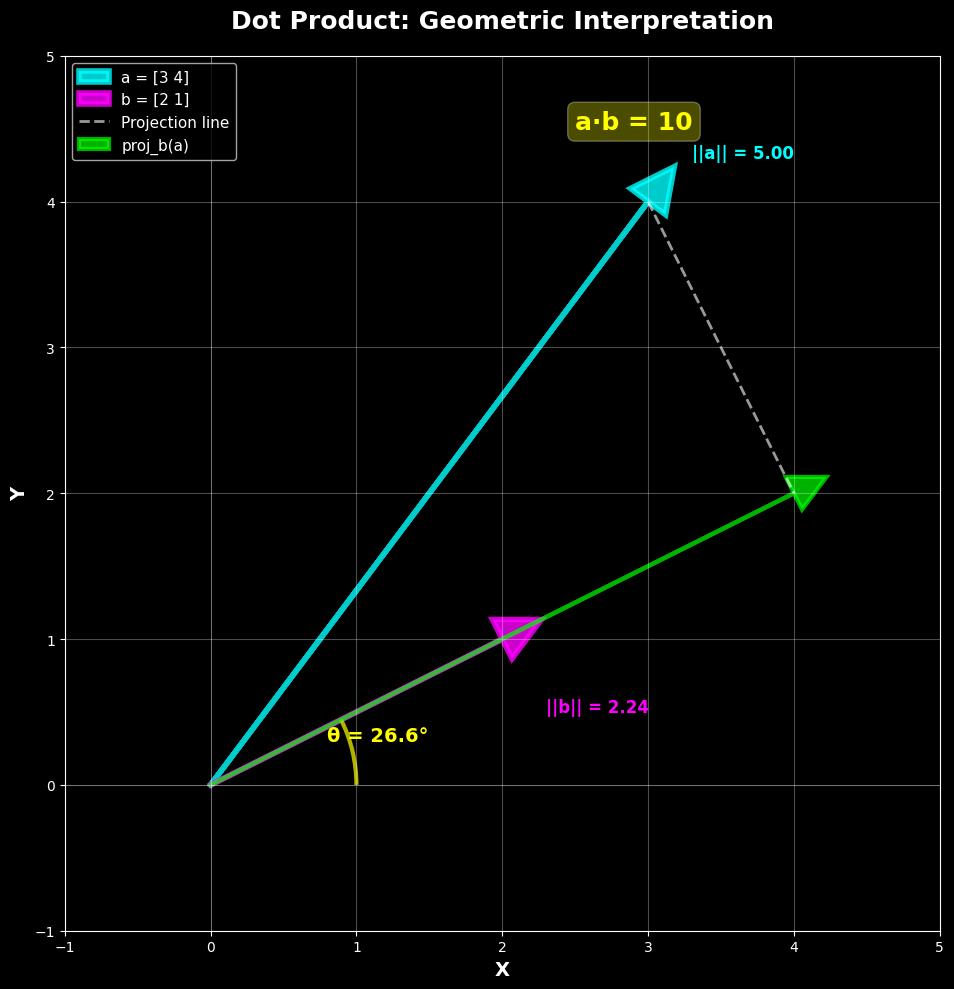

In [5]:
# Visualize vectors and their dot product
fig, ax = plt.subplots(figsize=(12, 10))

# Plot vectors
ax.arrow(0, 0, a[0], a[1], head_width=0.3, head_length=0.3,
         fc='cyan', ec='cyan', linewidth=4, alpha=0.8, label=f'a = {a}')
ax.arrow(0, 0, b[0], b[1], head_width=0.3, head_length=0.3,
         fc='magenta', ec='magenta', linewidth=4, alpha=0.8, label=f'b = {b}')

# Draw angle arc
from matplotlib.patches import Arc
arc = Arc((0, 0), 2, 2, angle=0, theta1=0, theta2=theta_deg,
          color='yellow', linewidth=3, alpha=0.7)
ax.add_patch(arc)
ax.text(0.8, 0.3, f'θ = {theta_deg:.1f}°', fontsize=14, 
        color='yellow', fontweight='bold')

# Project a onto b (visual)

projection_scalar = dot_algebraic / (magnitude_b ** 2)
print("projection_scalar: ", projection_scalar)
projection_vector = projection_scalar * b

# Draw projection
ax.plot([a[0], projection_vector[0]], [a[1], projection_vector[1]],
        'white', linewidth=2, linestyle='--', alpha=0.6, label='Projection line')
ax.arrow(0, 0, projection_vector[0], projection_vector[1],
         head_width=0.25, head_length=0.25, fc='lime', ec='lime',
         linewidth=3, alpha=0.7, label='proj_b(a)')

# Add text annotations
ax.text(a[0]+0.3, a[1]+0.3, f'||a|| = {magnitude_a:.2f}',
        fontsize=12, color='cyan', fontweight='bold')
ax.text(b[0]+0.3, b[1]-0.5, f'||b|| = {magnitude_b:.2f}',
        fontsize=12, color='magenta', fontweight='bold')

# Add dot product result
ax.text(2.5, 4.5, f'a·b = {dot_algebraic}', fontsize=18,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3),
        color='yellow', fontweight='bold')

ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_xlabel('X', fontsize=14, fontweight='bold')
ax.set_ylabel('Y', fontsize=14, fontweight='bold')
ax.set_title('Dot Product: Geometric Interpretation', fontsize=18, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. Dot Product and Angle Relationship
**Understanding alignment through different angles**

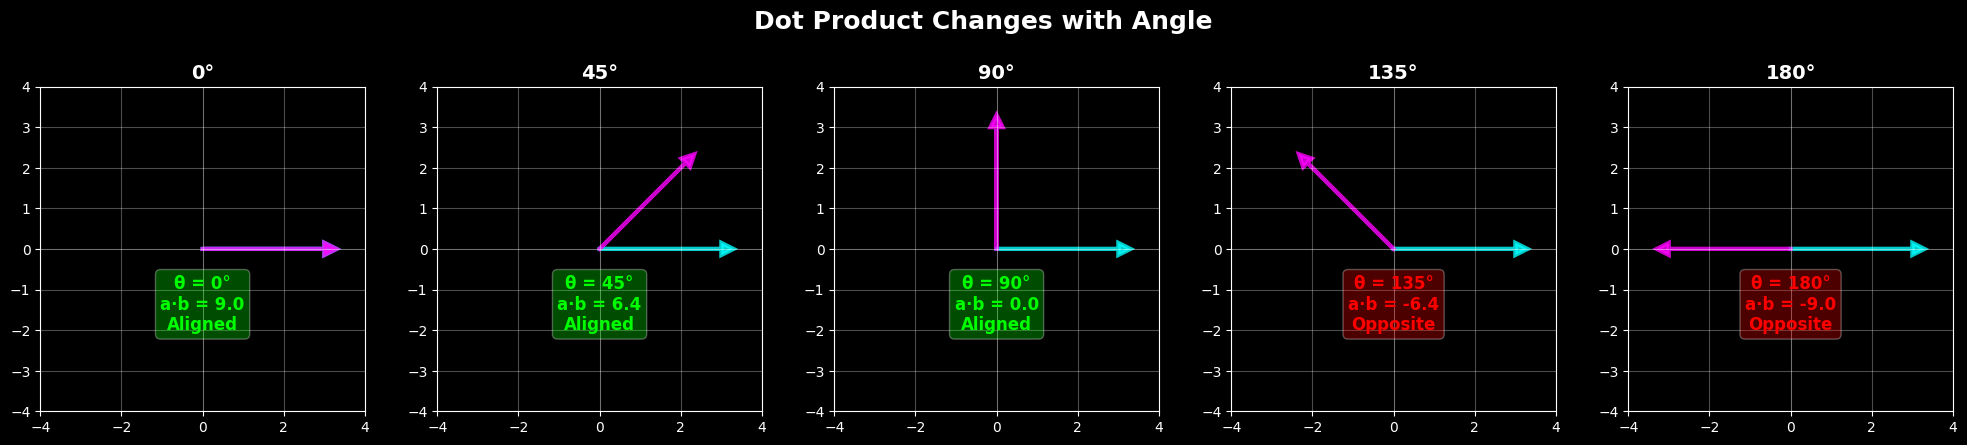

Key Insights:
  0° (Same direction):    a·b > 0 (Maximum: ||a|| × ||b||)
  90° (Perpendicular):    a·b = 0 (Orthogonal)
  180° (Opposite):        a·b < 0 (Minimum: -||a|| × ||b||)


In [ ]:
# Create vectors at different angles
base_vector = np.array([3, 0])  # Along x-axis

angles_deg = [0, 45, 90, 135, 180]
angles_rad = np.radians(angles_deg)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (angle_deg, angle_rad) in enumerate(zip(angles_deg, angles_rad)):
    ax = axes[idx]
    
    # Create rotated vector
    rotated_vector = np.array([3 * np.cos(angle_rad), 3 * np.sin(angle_rad)])
    
    # Calculate dot product
    dot = np.dot(base_vector, rotated_vector)
    
    # Plot vectors
    ax.arrow(0, 0, base_vector[0], base_vector[1],
            head_width=0.3, head_length=0.3, fc='cyan', ec='cyan',
            linewidth=3, alpha=0.8)
    ax.arrow(0, 0, rotated_vector[0], rotated_vector[1],
            head_width=0.3, head_length=0.3, fc='magenta', ec='magenta',
            linewidth=3, alpha=0.8)
    
    # Determine color based on dot product
    if dot > 0:
        color = 'lime'
        alignment = 'Aligned'
    elif dot == 0:
        color = 'yellow'
        alignment = 'Orthogonal'
    else:
        color = 'red'
        alignment = 'Opposite'
    
    ax.text(0, -2, f'θ = {angle_deg}°\na·b = {dot:.1f}\n{alignment}',
           fontsize=12, ha='center', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor=color, alpha=0.3),
           color=color)
    
    ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.set_title(f'{angle_deg}°', fontsize=14, fontweight='bold')

plt.suptitle('Dot Product Changes with Angle', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Key Insights:")
print("  0° (Same direction):    a·b > 0 (Maximum: ||a|| × ||b||)")
print("  90° (Perpendicular):    a·b = 0 (Orthogonal)")
print("  180° (Opposite):        a·b < 0 (Minimum: -||a|| × ||b||)")

## 4. Cosine Similarity from Dot Product
**Normalized dot product for comparing vectors**

Document Vectors (word frequencies):
  Doc1: [3 2 1 4]
  Doc2: [2 3 2 3]
  Doc3: [1 0 5 1]

Raw Dot Products:
  Doc1·Doc2 = 26
  Doc1·Doc3 = 12
  Doc2·Doc3 = 15

Cosine Similarities (normalized):
  sim(Doc1, Doc2) = 0.9309 ← Most similar
  sim(Doc1, Doc3) = 0.4216
  sim(Doc2, Doc3) = 0.5661


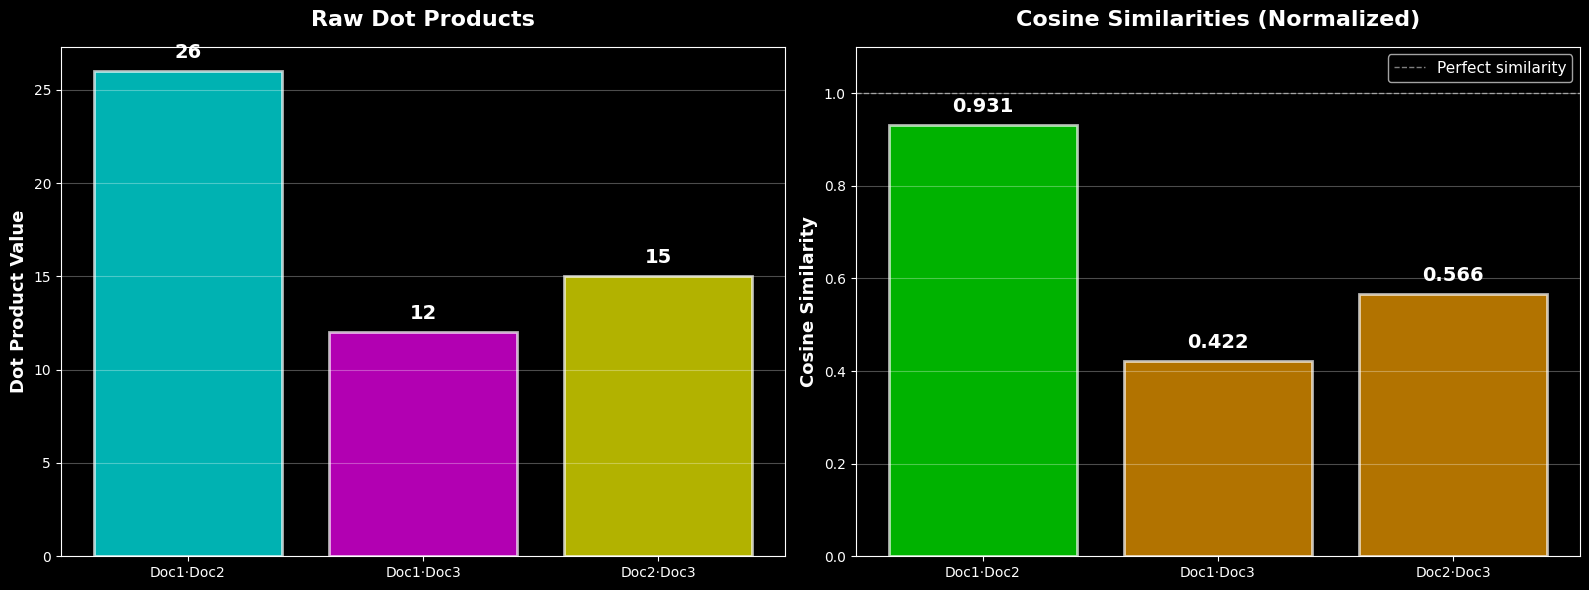


💡 Cosine similarity normalizes dot product to range [-1, 1]
   Perfect for comparing vectors of different magnitudes!


In [ ]:
# Create sample vectors (documents, user preferences, etc.)
doc1 = np.array([3, 2, 1, 4])  # Word frequencies in document 1
doc2 = np.array([2, 3, 2, 3])  # Similar document
doc3 = np.array([1, 0, 5, 1])  # Different document

def cosine_similarity(v1, v2):
    """Compute cosine similarity using dot product"""
    dot_product = np.dot(v1, v2)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)
    return dot_product / (magnitude_v1 * magnitude_v2)

# Calculate similarities
sim_12 = cosine_similarity(doc1, doc2)
sim_13 = cosine_similarity(doc1, doc3)
sim_23 = cosine_similarity(doc2, doc3)

# Calculate raw dot products for comparison
dot_12 = np.dot(doc1, doc2)
dot_13 = np.dot(doc1, doc3)
dot_23 = np.dot(doc2, doc3)

print("Document Vectors (word frequencies):")
print(f"  Doc1: {doc1}")
print(f"  Doc2: {doc2}")
print(f"  Doc3: {doc3}")
print("\nRaw Dot Products:")
print(f"  Doc1·Doc2 = {dot_12}")
print(f"  Doc1·Doc3 = {dot_13}")
print(f"  Doc2·Doc3 = {dot_23}")
print("\nCosine Similarities (normalized):")
print(f"  sim(Doc1, Doc2) = {sim_12:.4f} ← Most similar")
print(f"  sim(Doc1, Doc3) = {sim_13:.4f}")
print(f"  sim(Doc2, Doc3) = {sim_23:.4f}")

# Visualize as bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Raw dot products
ax1 = axes[0]
comparisons = ['Doc1·Doc2', 'Doc1·Doc3', 'Doc2·Doc3']
dot_values = [dot_12, dot_13, dot_23]
colors_dot = ['cyan', 'magenta', 'yellow']

bars1 = ax1.bar(comparisons, dot_values, color=colors_dot, alpha=0.7, edgecolor='white', linewidth=2)
ax1.set_ylabel('Dot Product Value', fontsize=13, fontweight='bold')
ax1.set_title('Raw Dot Products', fontsize=16, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, dot_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Plot 2: Cosine similarities
ax2 = axes[1]
sim_values = [sim_12, sim_13, sim_23]
colors_sim = ['lime' if s == max(sim_values) else 'orange' for s in sim_values]

bars2 = ax2.bar(comparisons, sim_values, color=colors_sim, alpha=0.7, edgecolor='white', linewidth=2)
ax2.set_ylabel('Cosine Similarity', fontsize=13, fontweight='bold')
ax2.set_title('Cosine Similarities (Normalized)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylim([0, 1.1])
ax2.axhline(y=1.0, color='white', linestyle='--', linewidth=1, alpha=0.5, label='Perfect similarity')
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=11)
for bar, val in zip(bars2, sim_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Cosine similarity normalizes dot product to range [-1, 1]")
print("   Perfect for comparing vectors of different magnitudes!")

## 5. Neural Networks: Dot Product Everywhere!
**Every neuron computation is a dot product**

Neural Network Layer Computation:

Input X: [0.5 0.8 0.3 0.9]

Neuron 1: W1·X + b1 = 0.780 → ReLU → 0.780
  W1·X breakdown: 0.2×0.5 + 0.5×0.8 + 0.3×0.3 + 0.1×0.9 = 0.680

Neuron 2: W2·X + b2 = 0.470 → ReLU → 0.470

Neuron 3: W3·X + b3 = 1.370 → ReLU → 1.370


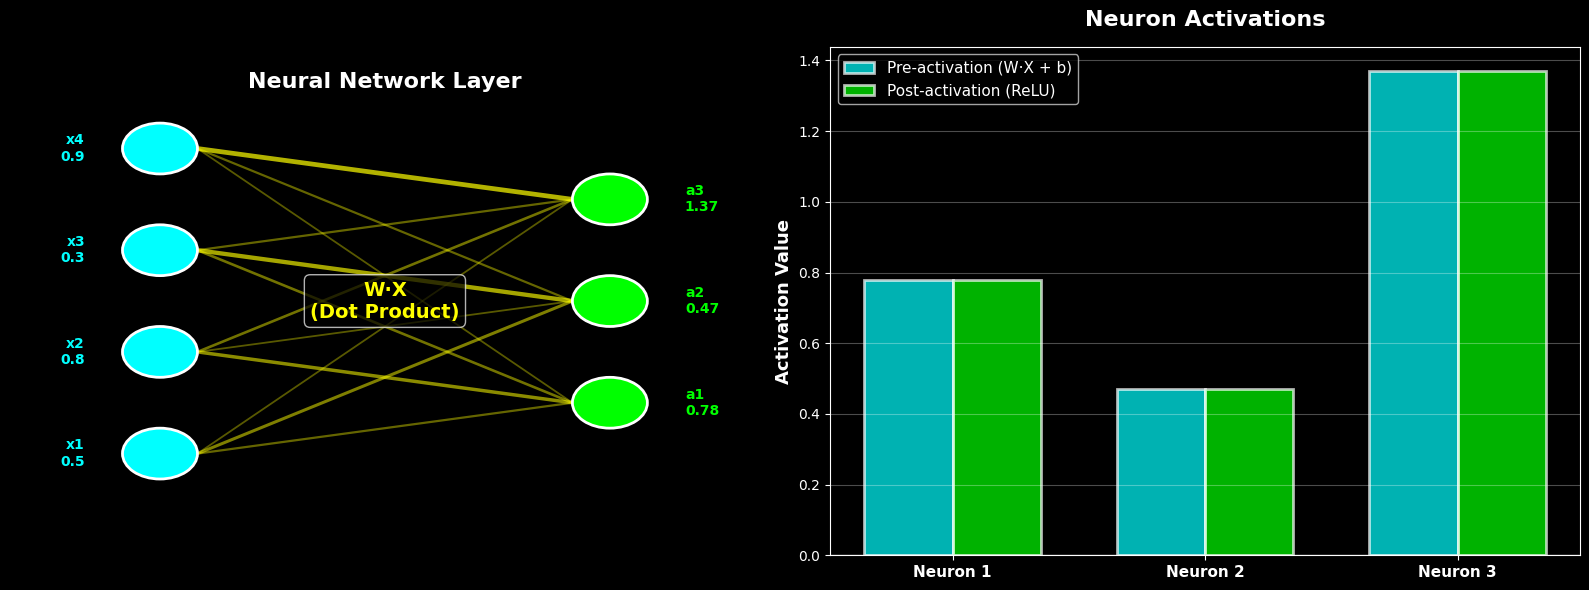


💡 Every neuron = Dot product + Bias + Activation
   Deep Learning = Millions of dot products!


In [ ]:
# Simple neural network layer computation
# Output = activation(W·X + b)

# Input features (e.g., image features)
X = np.array([0.5, 0.8, 0.3, 0.9])  # 4 input features

# Weights for 3 neurons
W1 = np.array([0.2, 0.5, 0.3, 0.1])  # Neuron 1 weights
W2 = np.array([0.4, 0.1, 0.7, 0.2])  # Neuron 2 weights
W3 = np.array([0.1, 0.3, 0.2, 0.8])  # Neuron 3 weights

# Biases
b1, b2, b3 = 0.1, -0.2, 0.3

# Compute dot products (pre-activation)
z1 = np.dot(W1, X) + b1
z2 = np.dot(W2, X) + b2
z3 = np.dot(W3, X) + b3

# Apply activation (ReLU)
def relu(x):
    return np.maximum(0, x)

a1 = relu(z1)
a2 = relu(z2)
a3 = relu(z3)

print("Neural Network Layer Computation:")
print(f"\nInput X: {X}")
print(f"\nNeuron 1: W1·X + b1 = {z1:.3f} → ReLU → {a1:.3f}")
print(f"  W1·X breakdown: {W1[0]:.1f}×{X[0]:.1f} + {W1[1]:.1f}×{X[1]:.1f} + {W1[2]:.1f}×{X[2]:.1f} + {W1[3]:.1f}×{X[3]:.1f} = {np.dot(W1, X):.3f}")
print(f"\nNeuron 2: W2·X + b2 = {z2:.3f} → ReLU → {a2:.3f}")
print(f"\nNeuron 3: W3·X + b3 = {z3:.3f} → ReLU → {a3:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Network architecture
ax1 = axes[0]
ax1.text(0.5, 0.95, 'Neural Network Layer', ha='center', va='top',
        fontsize=16, fontweight='bold', transform=ax1.transAxes)

# Input layer
input_y = np.linspace(0.2, 0.8, 4)
for i, (y, val) in enumerate(zip(input_y, X)):
    circle = plt.Circle((0.2, y), 0.05, color='cyan', ec='white', linewidth=2, zorder=3)
    ax1.add_patch(circle)
    ax1.text(0.1, y, f'x{i+1}\n{val:.1f}', ha='right', va='center',
            fontsize=10, fontweight='bold', color='cyan')

# Output layer
output_y = np.linspace(0.3, 0.7, 3)
outputs = [a1, a2, a3]
for i, (y, val) in enumerate(zip(output_y, outputs)):
    circle = plt.Circle((0.8, y), 0.05, color='lime', ec='white', linewidth=2, zorder=3)
    ax1.add_patch(circle)
    ax1.text(0.9, y, f'a{i+1}\n{val:.2f}', ha='left', va='center',
            fontsize=10, fontweight='bold', color='lime')

# Connections (weights)
weights_list = [W1, W2, W3]
for out_idx, (out_y, weights) in enumerate(zip(output_y, weights_list)):
    for in_idx, in_y in enumerate(input_y):
        alpha = abs(weights[in_idx])
        color = 'yellow' if weights[in_idx] > 0 else 'red'
        ax1.plot([0.25, 0.75], [in_y, out_y], color=color,
                linewidth=1+alpha*3, alpha=0.3+alpha*0.5, zorder=1)

ax1.text(0.5, 0.5, 'W·X\n(Dot Product)', ha='center', va='center',
        fontsize=14, fontweight='bold', color='yellow',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Plot 2: Activation values
ax2 = axes[1]
neurons = ['Neuron 1', 'Neuron 2', 'Neuron 3']
pre_activation = [z1, z2, z3]
post_activation = [a1, a2, a3]

x_pos = np.arange(len(neurons))
width = 0.35

bars1 = ax2.bar(x_pos - width/2, pre_activation, width, label='Pre-activation (W·X + b)',
               color='cyan', alpha=0.7, edgecolor='white', linewidth=2)
bars2 = ax2.bar(x_pos + width/2, post_activation, width, label='Post-activation (ReLU)',
               color='lime', alpha=0.7, edgecolor='white', linewidth=2)

ax2.set_ylabel('Activation Value', fontsize=13, fontweight='bold')
ax2.set_title('Neuron Activations', fontsize=16, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(neurons, fontsize=11, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='white', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("\n💡 Every neuron = Dot product + Bias + Activation")
print("   Deep Learning = Millions of dot products!")

## 6. Matrix-Vector Multiplication = Batch Dot Products
**Efficient computation using matrices**

Matrix Formulation:

Weight Matrix W (3×4):
[[0.2 0.5 0.3 0.1]
 [0.4 0.1 0.7 0.2]
 [0.1 0.3 0.2 0.8]]

Input Vector X (4,): [0.5 0.8 0.3 0.9]

Bias Vector b (3,): [ 0.1 -0.2  0.3]

Z = W @ X + b = [0.78 0.47 1.37]
A = ReLU(Z) = [0.78 0.47 1.37]

Matrix multiplication breaks down to:
  Row 1 · X = Neuron 1 output
  Row 2 · X = Neuron 2 output
  Row 3 · X = Neuron 3 output

Each row-vector dot product = One neuron!


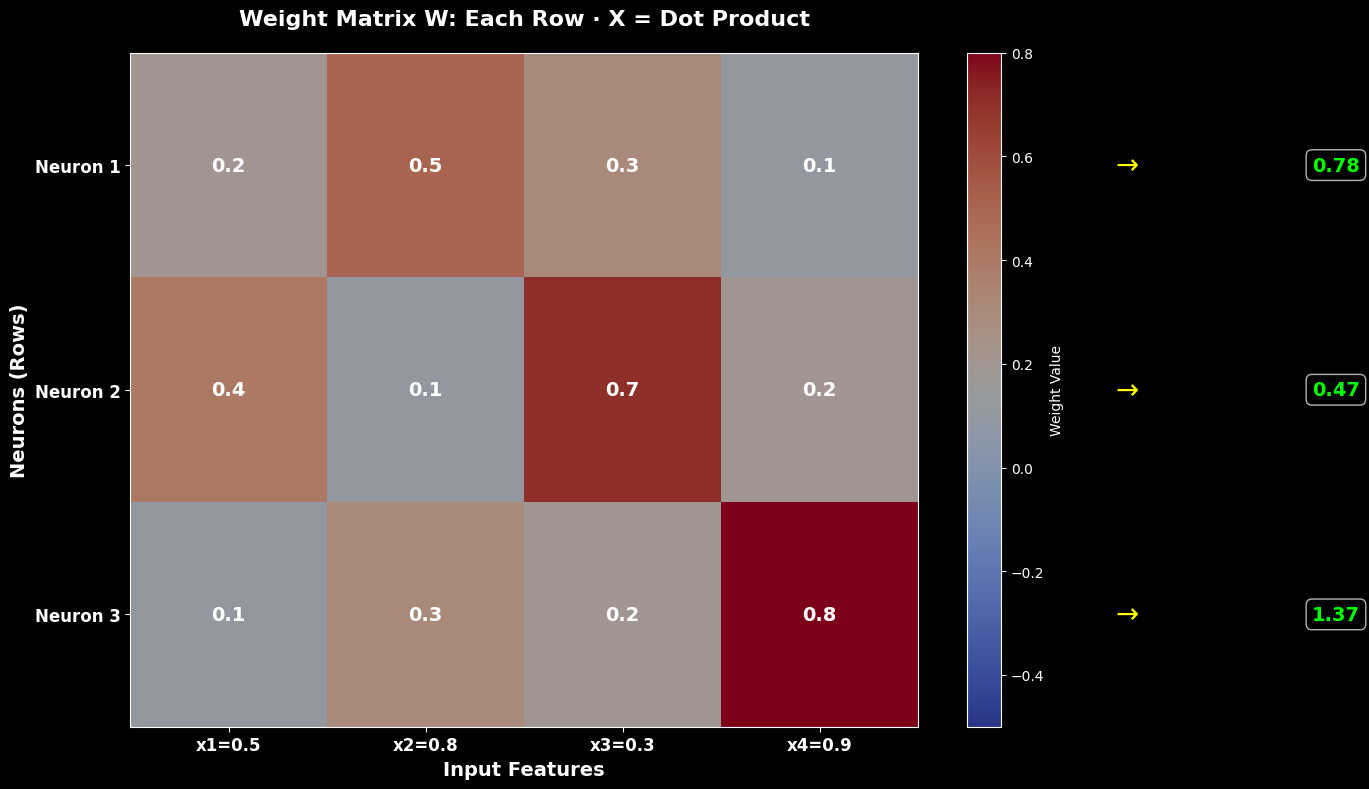


💡 GPU acceleration = Parallel dot products!
   1000s of neurons computed simultaneously


In [ ]:
# Previous example as matrix multiplication
X = np.array([0.5, 0.8, 0.3, 0.9])  # Input vector (4,)

# Stack all weight vectors into a matrix
W = np.array([
    [0.2, 0.5, 0.3, 0.1],  # Neuron 1
    [0.4, 0.1, 0.7, 0.2],  # Neuron 2
    [0.1, 0.3, 0.2, 0.8]   # Neuron 3
])  # Shape: (3, 4)

b = np.array([0.1, -0.2, 0.3])  # Biases (3,)

# Matrix-vector multiplication (all dot products at once!)
Z = W @ X + b  # Shape: (3,)
A = relu(Z)

print("Matrix Formulation:")
print(f"\nWeight Matrix W (3×4):\n{W}")
print(f"\nInput Vector X (4,): {X}")
print(f"\nBias Vector b (3,): {b}")
print(f"\nZ = W @ X + b = {Z}")
print(f"A = ReLU(Z) = {A}")

print("\n" + "="*50)
print("Matrix multiplication breaks down to:")
print("  Row 1 · X = Neuron 1 output")
print("  Row 2 · X = Neuron 2 output")
print("  Row 3 · X = Neuron 3 output")
print("\nEach row-vector dot product = One neuron!")
print("="*50)

# Visualize matrix multiplication as dot products
fig, ax = plt.subplots(figsize=(14, 8))

# Display weight matrix
im = ax.imshow(W, cmap='coolwarm', aspect='auto', alpha=0.7, vmin=-0.5, vmax=0.8)

# Add text annotations
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        text = ax.text(j, i, f'{W[i, j]:.1f}',
                      ha="center", va="center", color="white",
                      fontsize=14, fontweight='bold')

# Labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(3))
ax.set_xticklabels([f'x{i+1}={X[i]:.1f}' for i in range(4)], fontsize=12, fontweight='bold')
ax.set_yticklabels([f'Neuron {i+1}' for i in range(3)], fontsize=12, fontweight='bold')

# Add arrows and results
for i in range(3):
    ax.text(4.5, i, '→', fontsize=20, va='center', color='yellow')
    ax.text(5.5, i, f'{Z[i]:.2f}', fontsize=14, va='center',
           fontweight='bold', color='lime',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

ax.set_xlabel('Input Features', fontsize=14, fontweight='bold')
ax.set_ylabel('Neurons (Rows)', fontsize=14, fontweight='bold')
ax.set_title('Weight Matrix W: Each Row · X = Dot Product', 
            fontsize=16, fontweight='bold', pad=20)

plt.colorbar(im, ax=ax, label='Weight Value')
plt.tight_layout()
plt.show()

print("\n💡 GPU acceleration = Parallel dot products!")
print("   1000s of neurons computed simultaneously")

## 7. Attention Mechanism: Dot Product as Similarity
**The secret behind Transformers**

Attention Mechanism for word 'cat':

Query (cat): [0.8 0.6 0.3 0.2]

Attention Scores (Q·K for each word):
  'the': 0.230
  'cat': 1.130
  'sat': 0.770
  'on': 0.200
  'mat': 0.980

Attention Weights (after softmax):
  'the': 0.121 (12.1%)
  'cat': 0.298 (29.8%)
  'sat': 0.208 (20.8%)
  'on': 0.117 (11.7%)
  'mat': 0.256 (25.6%)


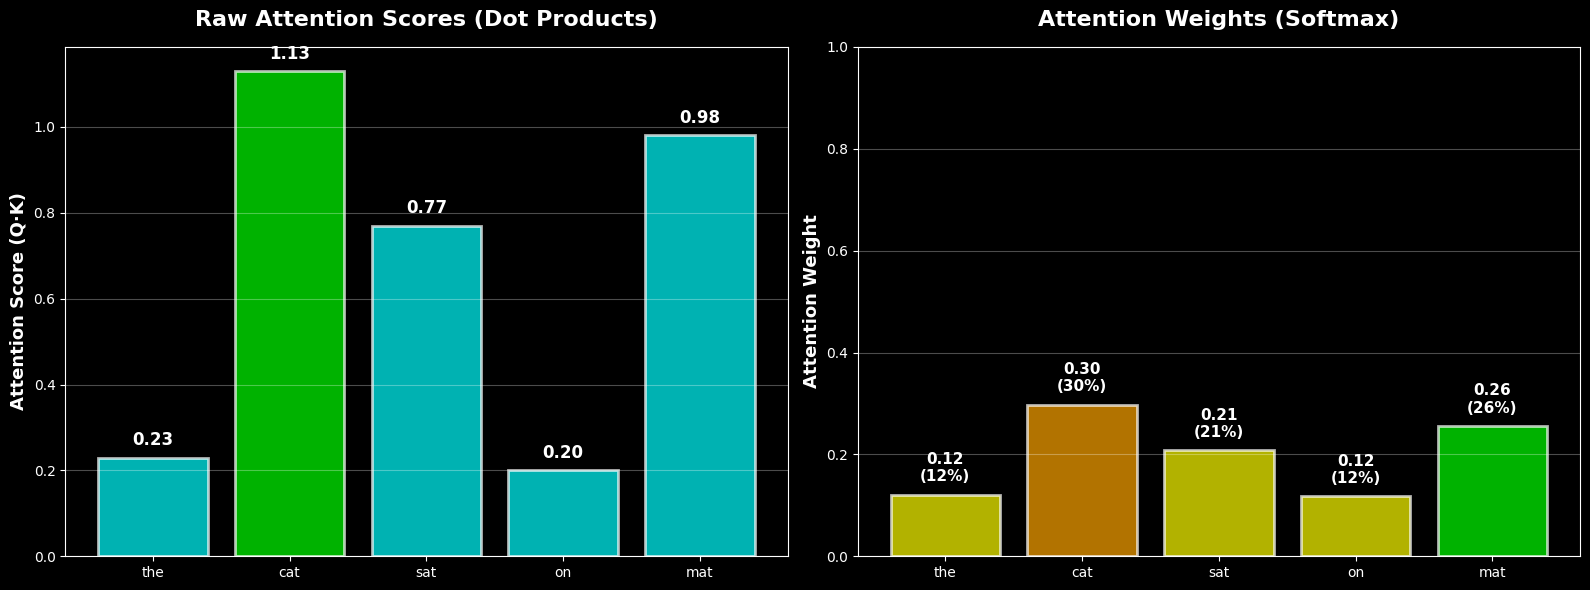


💡 Attention = Dot product between Query and Keys!
   Higher dot product = More attention = More relevant

   'cat' pays most attention to 'mat' and itself!


In [ ]:
# Simplified attention mechanism
# Query: What am I looking for?
# Key: What do I contain?
# Value: What do I actually output?

# Example: "The cat sat on the mat"
# Word embeddings (simplified to 4D)
words = ['the', 'cat', 'sat', 'on', 'mat']

# Simulated embeddings
embeddings = np.array([
    [0.1, 0.2, 0.1, 0.0],  # the
    [0.8, 0.6, 0.3, 0.2],  # cat
    [0.3, 0.4, 0.9, 0.1],  # sat
    [0.1, 0.1, 0.2, 0.0],  # on
    [0.7, 0.5, 0.2, 0.3],  # mat
])

# Let's compute attention for the word "cat" (index 1)
query = embeddings[1]  # cat's query

# Compute attention scores using dot product
attention_scores = []
for i, key in enumerate(embeddings):
    score = np.dot(query, key)  # Dot product!
    attention_scores.append(score)

attention_scores = np.array(attention_scores)

# Apply softmax to get attention weights
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Numerical stability
    return exp_x / exp_x.sum()

attention_weights = softmax(attention_scores)

print("Attention Mechanism for word 'cat':")
print("\nQuery (cat):", query)
print("\nAttention Scores (Q·K for each word):")
for word, score in zip(words, attention_scores):
    print(f"  '{word}': {score:.3f}")

print("\nAttention Weights (after softmax):")
for word, weight in zip(words, attention_weights):
    print(f"  '{word}': {weight:.3f} ({weight*100:.1f}%)")

# Visualize attention
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Attention scores (raw dot products)
ax1 = axes[0]
colors_1 = ['lime' if w == words[1] else 'cyan' for w in words]
bars1 = ax1.bar(words, attention_scores, color=colors_1, alpha=0.7,
               edgecolor='white', linewidth=2)
ax1.set_ylabel('Attention Score (Q·K)', fontsize=13, fontweight='bold')
ax1.set_title('Raw Attention Scores (Dot Products)', fontsize=16, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)
for bar, score in zip(bars1, attention_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{score:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: Attention weights (after softmax)
ax2 = axes[1]
colors_2 = ['lime' if w == 'mat' else 'orange' if w == 'cat' else 'yellow' for w in words]
bars2 = ax2.bar(words, attention_weights, color=colors_2, alpha=0.7,
               edgecolor='white', linewidth=2)
ax2.set_ylabel('Attention Weight', fontsize=13, fontweight='bold')
ax2.set_title('Attention Weights (Softmax)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylim([0, 1])        
ax2.grid(axis='y', alpha=0.3)
for bar, weight in zip(bars2, attention_weights):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{weight:.2f}\n({weight*100:.0f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Attention = Dot product between Query and Keys!")
print("   Higher dot product = More attention = More relevant")
print("\n   'cat' pays most attention to 'mat' and itself!")

## 8. Projection: Another Key Use of Dot Product
**Project one vector onto another**

Vector Projection:

a = [4 3]
b = [3 1]

Projection of a onto b:
  proj_b(a) = (a·b / ||b||²) × b
  proj_b(a) = (15 / 10) × [3 1]
  proj_b(a) = [4.5 1.5]

Perpendicular component: [-0.5  1.5]

Verification: projection + perpendicular = [4. 3.]


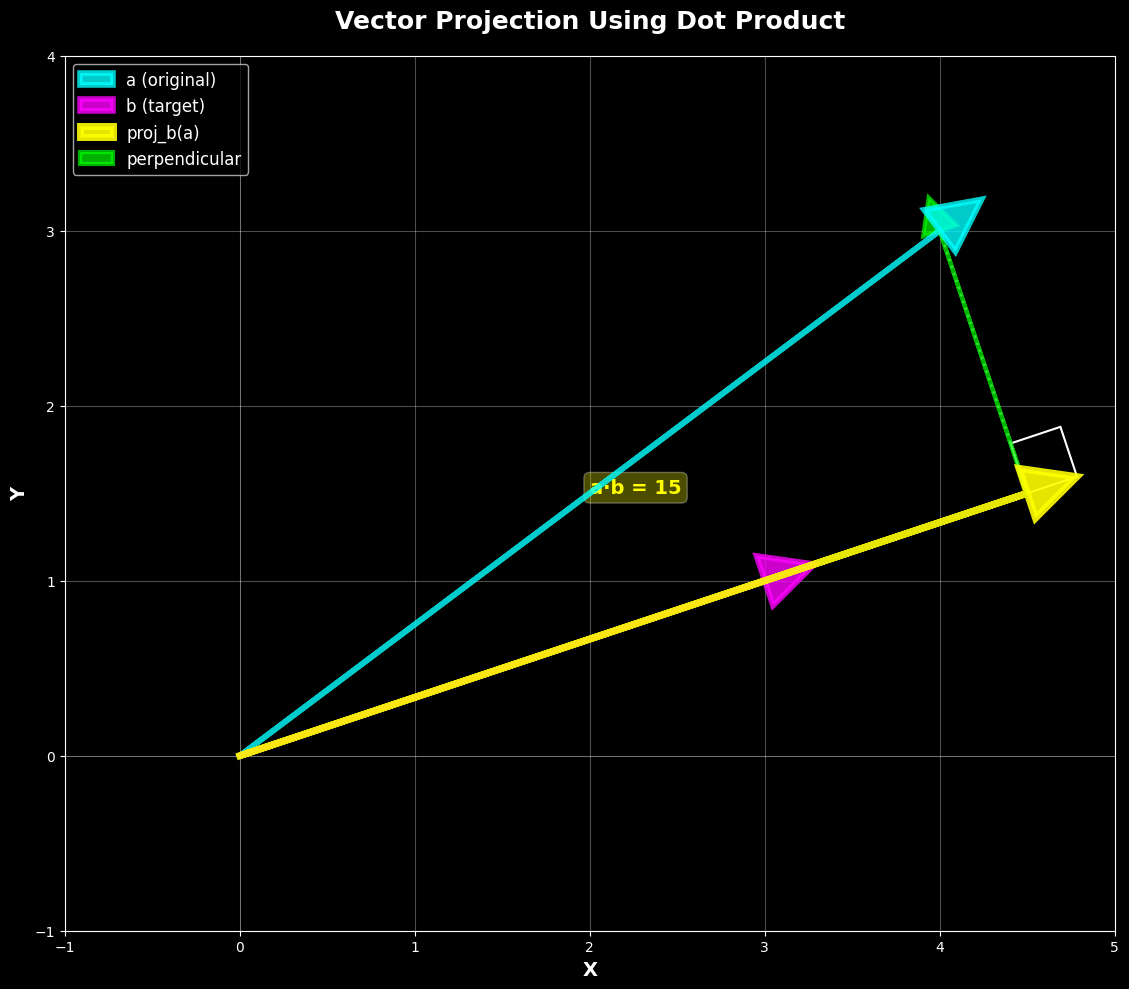


💡 Projection decompose a vector into parallel and perpendicular components
   Used in: PCA, Gram-Schmidt, regression, feature extraction


In [ ]:
# Vector projection using dot product
# proj_b(a) = (a·b / ||b||²) * b

a = np.array([4, 3])
b = np.array([3, 1])

# Calculate projection
dot_ab = np.dot(a, b)
magnitude_b_squared = np.dot(b, b)
projection_scalar = dot_ab / magnitude_b_squared
projection = projection_scalar * b

# Perpendicular component
perpendicular = a - projection

print("Vector Projection:")
print(f"\na = {a}")
print(f"b = {b}")
print(f"\nProjection of a onto b:")
print(f"  proj_b(a) = (a·b / ||b||²) × b")
print(f"  proj_b(a) = ({dot_ab} / {magnitude_b_squared}) × {b}")
print(f"  proj_b(a) = {projection}")
print(f"\nPerpendicular component: {perpendicular}")
print(f"\nVerification: projection + perpendicular = {projection + perpendicular}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 10))

# Original vectors
ax.arrow(0, 0, a[0], a[1], head_width=0.3, head_length=0.3,
         fc='cyan', ec='cyan', linewidth=4, alpha=0.8, label='a (original)', zorder=5)
ax.arrow(0, 0, b[0], b[1], head_width=0.3, head_length=0.3,
         fc='magenta', ec='magenta', linewidth=4, alpha=0.8, label='b (target)', zorder=5)

# Projection
ax.arrow(0, 0, projection[0], projection[1], head_width=0.3, head_length=0.3,
         fc='yellow', ec='yellow', linewidth=5, alpha=0.9, label='proj_b(a)', zorder=6)

# Perpendicular component
ax.arrow(projection[0], projection[1], perpendicular[0], perpendicular[1],
         head_width=0.2, head_length=0.2, fc='lime', ec='lime',
         linewidth=3, alpha=0.7, label='perpendicular', zorder=4)

# Draw dotted line from a to projection
ax.plot([a[0], projection[0]], [a[1], projection[1]],
        'white', linewidth=2, linestyle=':', alpha=0.6)

# Right angle marker
from matplotlib.patches import Rectangle
angle_size = 0.3
b_unit = b / np.linalg.norm(b)
perp_unit = perpendicular / np.linalg.norm(perpendicular) if np.linalg.norm(perpendicular) > 0 else perpendicular
corner = projection
square = plt.Polygon([corner, corner + angle_size * b_unit, 
                      corner + angle_size * b_unit + angle_size * perp_unit,
                      corner + angle_size * perp_unit],
                     fill=False, edgecolor='white', linewidth=1.5)
ax.add_patch(square)

# Annotations
ax.text(2, 1.5, f'a·b = {dot_ab}', fontsize=14, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3), color='yellow')

ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.set_xlabel('X', fontsize=14, fontweight='bold')
ax.set_ylabel('Y', fontsize=14, fontweight='bold')
ax.set_title('Vector Projection Using Dot Product', fontsize=18, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("\n💡 Projection decompose a vector into parallel and perpendicular components")
print("   Used in: PCA, Gram-Schmidt, regression, feature extraction")

## 9. Key Takeaways

### Dot Product Definition:
**Algebraic:** `a·b = Σ(aᵢ × bᵢ) = a₁b₁ + a₂b₂ + ... + aₙbₙ`

**Geometric:** `a·b = ||a|| × ||b|| × cos(θ)`

### Why It Matters in ML:

**1. Similarity Measurement**
- Cosine similarity = Normalized dot product
- Recommendation systems
- Document similarity
- Image retrieval

**2. Neural Networks**
- Every neuron: `output = activation(W·X + b)`
- Matrix multiplication = Batch dot products
- Backpropagation gradients

**3. Attention Mechanisms**
- Query · Key = Attention score
- Transformers (BERT, GPT, etc.)
- Self-attention, cross-attention

**4. Projections**
- PCA (Principal Component Analysis)
- Feature extraction
- Dimensionality reduction

### Key Properties:
- `a·b = b·a` (Commutative)
- `a·(b+c) = a·b + a·c` (Distributive)
- `(ka)·b = k(a·b)` (Scalar multiplication)
- `a·a = ||a||²` (Self dot product)
- `a·b = 0` ⟺ vectors are orthogonal (perpendicular)

### Computational Complexity:
- **Time:** O(n) for n-dimensional vectors
- **Space:** O(1) for result storage
- **GPU acceleration:** Massive parallelization possible
- **NumPy/CUDA:** Highly optimized implementations

### Remember:
**Master dot product = Master 80% of ML math!** 🚀

Every time you see:
- Matrix multiplication → Dot products
- Neural network forward pass → Dot products
- Attention scores → Dot products
- Similarity metrics → Dot products

**It's dot products all the way down!**